# Random Forest – (vlagunr-Cyano.csv)


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import export_graphviz
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid')
np.random.seed(42)

base_dir = Path.cwd()
data_path = base_dir / 'vlagunr-Cyano.csv'
target_col = 'CyanobacteriaBiomassC'

print('Katalog roboczy:', base_dir)
print('Plik danych:', data_path)

Katalog roboczy: C:\Users\mix13\Documents\GitHub\WBD\PythonProject\RF
Plik danych: C:\Users\mix13\Documents\GitHub\WBD\PythonProject\RF\vlagunr-Cyano.csv


## 1. Wczytanie danych

In [20]:
df = pd.read_csv(data_path)
display(df.head())
print('Ksztalt:', df.shape)
print('Statystyki zmiennej docelowej:')
display(df[target_col].describe().to_frame())

,PSU,O2,temp.,SS,SRP,DOP,PP,NH4N,NO3N,DON,...,TN/TP,Fe,SiO4Si,ChlorophyceaeBiomassC,DiatomsBiomassC,PicoplanktonBiomassC,Windspeedinsitu,Depth,DIN to DIP,CyanobacteriaBiomassC
0,3.758,9.46,18.3,52.0,3.5,11.7,185.0,0.039,0.022,0.551,...,6.848,0.012,2.311,0.508,0.018,0.691,3.5,3.3,17.429,0.429
1,3.505,9.89,19.1,50.0,4.4,17.5,111.3,0.020,0.025,0.123,...,10.128,0.014,2.116,0.473,0.001,0.522,0.0,3.6,10.227,1.085
2,3.758,9.66,18.1,59.0,3.2,22.8,103.4,0.016,0.008,0.582,...,9.134,0.037,2.264,0.271,0.021,0.538,1.0,3.4,7.500,1.734
3,3.107,10.36,19.5,46.0,4.3,22.3,92.7,0.026,0.021,0.693,...,11.978,0.017,2.262,0.458,0.122,0.655,0.0,2.9,10.930,0.814
4,2.619,11.56,19.0,42.0,11.7,30.3,73.2,0.022,0.048,0.383,...,12.665,0.024,2.216,0.328,0.085,0.182,0.0,3.0,5.983,1.133


Ksztalt: (156, 21)
Statystyki zmiennej docelowej:


,CyanobacteriaBiomassC
count,156.000000
mean,0.709897
std,0.530361
min,0.016000
25%,0.245000
50%,0.632500
75%,1.023000
max,2.862000


In [21]:
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Cechy ({len(feature_cols)}):', feature_cols)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Cechy (20): ['PSU', 'O2', 'temp.', 'SS', 'SRP', 'DOP', 'PP', 'NH4N', 'NO3N', 'DON', 'PN', 'TN/TP', 'Fe', 'SiO4Si', 'ChlorophyceaeBiomassC', 'DiatomsBiomassC', 'PicoplanktonBiomassC', 'Windspeedinsitu', 'Depth', 'DIN to DIP']
Train: (109, 20) | Test: (47, 20)


## 2. Funkcje pomocnicze – metryki i modele

In [22]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mean_y = np.mean(y_true)
    mae_mean_ratio = mae / mean_y if mean_y != 0 else np.nan
    evs = explained_variance_score(y_true, y_pred)

    eps = 1e-10
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))
    accuracy = 1.0 - mape

    return {
        'MAE': mae,
        'MAE/Mean': mae_mean_ratio,
        'MSE': mse,
        'Explained_Variance': evs,
        'MAPE': mape,
        'Accuracy': accuracy,
    }


def evaluate_model(model, X_tr, y_tr, X_te, y_te, label):
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)

    rows = []
    for subset, y_true, y_pred in [
        ('train', y_tr, pred_train),
        ('test', y_te, pred_test),
    ]:
        m = regression_metrics(y_true, y_pred)
        m['zbior'] = subset
        m['wariant'] = label
        rows.append(m)
    return pd.DataFrame(rows)


def fit_rf(X_tr, y_tr, **kwargs):
    model = RandomForestRegressor(random_state=42, n_jobs=-1, **kwargs)
    model.fit(X_tr, y_tr)
    return model


def importance_series(model, all_features):
    return pd.Series(model.feature_importances_, index=all_features).sort_values(ascending=False)


def top_features_from_importance(imp, n_top=None):
    if n_top is not None:
        imp = imp.head(n_top)
    return imp.index.tolist(), imp


def features_after_importance_reduction(imp, reduction=0.10):
  # redukcja 10% najmniej istotnej masy waznosci (zostaje 90% waznosci)
    imp_sorted = imp.sort_values(ascending=False)
    cum_ratio = imp_sorted.cumsum() / imp_sorted.sum()
    kept = imp_sorted[cum_ratio <= (1.0 - reduction)]
    if kept.empty:
        kept = imp_sorted.head(1)
    return kept.index.tolist(), kept


def selected_features_from_pipeline(pipeline, all_features):
    mask = pipeline.named_steps['select'].get_support()
    return list(np.array(all_features)[mask])


def make_rf_selection_pipeline():
    return Pipeline([
        ('select', SelectFromModel(
            RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
            threshold='mean',
        )),
        ('rf', RandomForestRegressor(random_state=42, n_jobs=-1)),
    ])

## 3. Model bazowy (wszystkie zmienne), hierarchia i ważność cech

In [23]:
base_model = fit_rf(X_train, y_train)
importance_all = importance_series(base_model, feature_cols)
top4_features, _ = top_features_from_importance(importance_all, n_top=4)
top2_features, _ = top_features_from_importance(importance_all, n_top=2)
features_reduced, importance_reduced = features_after_importance_reduction(importance_all, reduction=0.10)

hierarchy_df = importance_all.sort_values(ascending=False).reset_index()
hierarchy_df.columns = ['parametr_srodowiskowy', 'waznosc']
hierarchy_df['rank'] = np.arange(1, len(hierarchy_df) + 1)
hierarchy_df = hierarchy_df[['rank', 'parametr_srodowiskowy', 'waznosc']]

print('Hierarchia parametrow srodowiskowych (od najwazniejszego):')
display(hierarchy_df)
print('2 najwazniejsze cechy:', top2_features)
print('Cechy po 10% redukcji waznosci:', features_reduced)
print('4 najwazniejsze cechy:', top4_features)

2 najwazniejsze cechy: ['NO3N', 'PN']
Cechy po usunieciu 10% najslabszych: ['NO3N', 'PN', 'NH4N', 'PSU', 'PicoplanktonBiomassC', 'DON', 'O2', 'temp.', 'TN/TP', 'SiO4Si', 'ChlorophyceaeBiomassC', 'SS', 'Fe', 'Windspeedinsitu', 'Depth', 'PP', 'DOP', 'DIN to DIP']
4 najwazniejsze cechy: ['NO3N', 'PN', 'NH4N', 'PSU', 'PicoplanktonBiomassC', 'DON', 'O2', 'temp.', 'TN/TP', 'SiO4Si', 'ChlorophyceaeBiomassC', 'SS', 'Fe', 'Windspeedinsitu', 'Depth', 'PP', 'DOP', 'DIN to DIP', 'DiatomsBiomassC', 'SRP']


,importance
NO3N,0.190776
PN,0.141473
NH4N,0.114510
PSU,0.090626
PicoplanktonBiomassC,0.077660
DON,0.057722
O2,0.052904
temp.,0.037531
TN/TP,0.034906
SiO4Si,0.026719


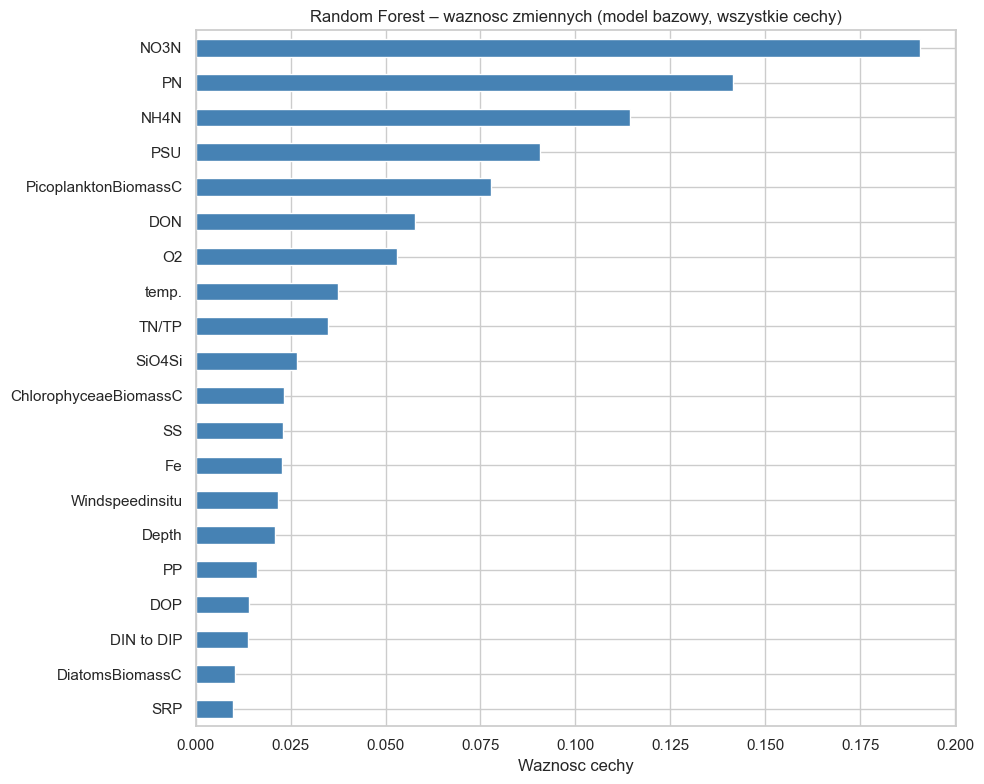

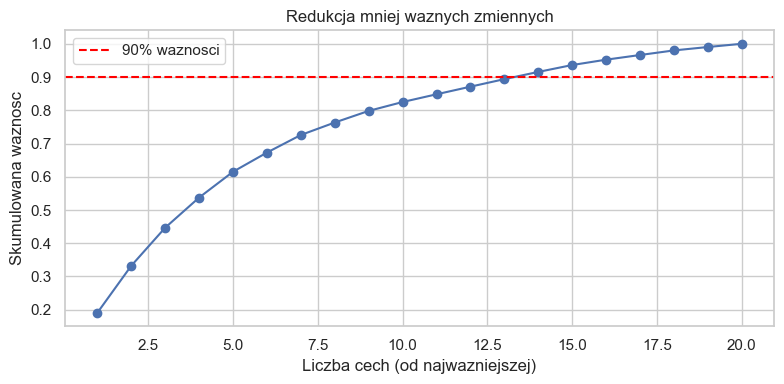

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
importance_all.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Waznosc cechy')
ax.set_title('Random Forest – waznosc zmiennych (model bazowy, wszystkie cechy)')
plt.tight_layout()
plt.show()

imp_sorted = importance_all.sort_values(ascending=False)
cum_ratio = imp_sorted.cumsum() / imp_sorted.sum()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum_ratio) + 1), cum_ratio.values, marker='o')
ax.axhline(0.90, color='red', linestyle='--', label='90% masy waznosci (po 10% redukcji)')
ax.set_xlabel('Liczba cech (od najwazniejszej)')
ax.set_ylabel('Skumulowana waznosc (udzial)')
ax.set_title('Diagram waznosci funkcji z redukcja mniej waznych zmiennych')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Porównanie wariantów modelu (train / test)

In [25]:
variant_results = []

# a) wszystkie zmienne
variant_results.append(evaluate_model(base_model, X_train, y_train, X_test, y_test, 'wszystkie zmienne'))

# b) 2 najwazniejsze cechy
model_top2 = fit_rf(X_train[top2_features], y_train)
variant_results.append(
    evaluate_model(model_top2, X_train[top2_features], y_train, X_test[top2_features], y_test, '2 najwazniejsze')
)

# c) po 10% redukcji skumulowanej waznosci
model_reduced = fit_rf(X_train[features_reduced], y_train)
variant_results.append(
    evaluate_model(
        model_reduced, X_train[features_reduced], y_train, X_test[features_reduced], y_test,
        'po 10% redukcji waznosci'
    )
)

metrics_variants = pd.concat(variant_results, ignore_index=True)
cols_order = ['wariant', 'zbior', 'MAE', 'MAE/Mean', 'MSE', 'Explained_Variance', 'MAPE', 'Accuracy']
metrics_variants = metrics_variants[cols_order]
display(metrics_variants.round(4))

,wariant,zbior,MAE,MAE/Mean,MSE,Explained_Variance,MAPE,Accuracy
0,wszystkie zmienne,train,0.1026,0.1448,0.0234,0.9162,0.2974,0.7026
1,wszystkie zmienne,test,0.3511,0.4923,0.2584,0.0886,0.7063,0.2937
2,2 najwazniejsze,train,0.1199,0.1693,0.0299,0.8926,0.3741,0.6259
3,2 najwazniejsze,test,0.4832,0.6774,0.3929,-0.3872,1.0245,-0.0245
4,po usunieciu 10% najslabszych,train,0.1061,0.1497,0.0242,0.9135,0.3038,0.6962
5,po usunieciu 10% najslabszych,test,0.3517,0.4931,0.2587,0.0879,0.7146,0.2854


## 5. RandomSearchCV i GridSearchCV (3-fold)

In [12]:
rf_pipeline = make_rf_selection_pipeline()

param_distributions = {
    'select__threshold': ['mean', 'median', 0.01, 0.02, 0.03, 0.05],
    'rf__n_estimators': [50, 100, 200, 300, 400],
    'rf__max_depth': [None, 5, 10, 15, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None],
}

param_grid = {
    'select__threshold': ['mean', 'median'],
    'rf__n_estimators': [100, 200, 300, 400],
    'rf__max_depth': [None, 5, 10, 15, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', None],
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    cv=3,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
)
random_search.fit(X_train, y_train)
random_pipeline = random_search.best_estimator_
random_model = random_pipeline.named_steps['rf']
random_features = selected_features_from_pipeline(random_pipeline, feature_cols)
print('RandomSearchCV – najlepsze parametry:')
print(random_search.best_params_)
print('Wybrane najwazniejsze zmienne:', random_features)

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
)
grid_search.fit(X_train, y_train)
grid_pipeline = grid_search.best_estimator_
grid_model = grid_pipeline.named_steps['rf']
grid_features = selected_features_from_pipeline(grid_pipeline, feature_cols)
print('GridSearchCV – najlepsze parametry:')
print(grid_search.best_params_)
print('Wybrane najwazniejsze zmienne:', grid_features)
print('Liczba kombinacji GridSearchCV:', len(grid_search.cv_results_['params']))

RandomSearchCV – najlepsze parametry:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
GridSearchCV – najlepsze parametry:
{'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Liczba kombinacji GridSearchCV: 288


In [13]:
variant_results.append(
    evaluate_model(
        random_pipeline, X_train, y_train, X_test, y_test,
        'najwazniejsze zmienne po RandomSearchCV'
    )
)
variant_results.append(
    evaluate_model(
        grid_pipeline, X_train, y_train, X_test, y_test,
        'najwazniejsze zmienne po GridSearchCV'
    )
)

metrics_variants = pd.concat(variant_results, ignore_index=True)[cols_order]
display(metrics_variants.round(4))

,wariant,zbior,MAE,MAE/Mean,MSE,Explained_Variance,MAPE,Accuracy
0,wszystkie zmienne,train,0.1026,0.1448,0.0234,0.9162,0.2974,0.7026
1,wszystkie zmienne,test,0.3511,0.4923,0.2584,0.0886,0.7063,0.2937
2,2 najwazniejsze,train,0.1199,0.1693,0.0299,0.8926,0.3741,0.6259
3,2 najwazniejsze,test,0.4832,0.6774,0.3929,-0.3872,1.0245,-0.0245
4,po usunieciu 10% najslabszych,train,0.1061,0.1497,0.0242,0.9135,0.3038,0.6962
5,po usunieciu 10% najslabszych,test,0.3517,0.4931,0.2587,0.0879,0.7146,0.2854
6,RandomSearchCV,train,0.1039,0.1466,0.0236,0.9155,0.2835,0.7165
7,RandomSearchCV,test,0.3420,0.4796,0.2429,0.1424,0.6672,0.3328
8,GridSearchCV,train,0.1039,0.1466,0.0236,0.9155,0.2835,0.7165
9,GridSearchCV,test,0.3420,0.4796,0.2429,0.1424,0.6672,0.3328


In [14]:
cv_compare = []
for name, model in [
    ('model bazowy (wszystkie zmienne)', base_model),
    ('RandomSearchCV', random_pipeline),
    ('GridSearchCV', grid_pipeline),
]:
    cv_compare.append(evaluate_model(model, X_train, y_train, X_test, y_test, name))

metrics_cv = pd.concat(cv_compare, ignore_index=True)[cols_order]
display(metrics_cv.round(4))

best_test = metrics_cv[metrics_cv['zbior'] == 'test'].sort_values('Accuracy', ascending=False).iloc[0]
display(Markdown(
    f"**Najwyzsza dokladnosc (Accuracy) na probie testowej:** `{best_test['wariant']}` "
    f"(Accuracy = {best_test['Accuracy']:.4f})"
))

,wariant,zbior,MAE,MAE/Mean,MSE,Explained_Variance,MAPE,Accuracy
0,model bazowy,train,0.1026,0.1448,0.0234,0.9162,0.2974,0.7026
1,model bazowy,test,0.3511,0.4923,0.2584,0.0886,0.7063,0.2937
2,RandomSearchCV,train,0.1039,0.1466,0.0236,0.9155,0.2835,0.7165
3,RandomSearchCV,test,0.3420,0.4796,0.2429,0.1424,0.6672,0.3328
4,GridSearchCV,train,0.1039,0.1466,0.0236,0.9155,0.2835,0.7165
5,GridSearchCV,test,0.3420,0.4796,0.2429,0.1424,0.6672,0.3328


**Najwyzsza dokladnosc (Accuracy) na probie testowej:** `GridSearchCV` (Accuracy = 0.3328)

## 6. Wizualizacja drzewa decyzyjnego (WebGraphviz)

Kod Graphviz zapisany do pliku `tree_cyano.dot` – wkleić tutaj: [WebGraphviz](http://www.webgraphviz.com/).

In [15]:
if 'GridSearchCV' in best_test['wariant']:
    tree_pipeline = grid_pipeline
elif 'RandomSearchCV' in best_test['wariant']:
    tree_pipeline = random_pipeline
else:
    tree_pipeline = None

if tree_pipeline is not None:
    tree_rf = tree_pipeline.named_steps['rf']
    tree_feature_names = selected_features_from_pipeline(tree_pipeline, feature_cols)
else:
    tree_rf = base_model
    tree_feature_names = list(feature_cols)

tree_for_viz = tree_rf.estimators_[0]
dot_path = base_dir / 'tree_cyano.dot'

export_graphviz(
    tree_for_viz,
    out_file=str(dot_path),
    feature_names=tree_feature_names,
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=4,
)

print('Zapisano:', dot_path)
print('Pierwsze 1500 znakow kodu drzewa:')
print(dot_path.read_text(encoding='utf-8')[:1500])

Zapisano: C:\Users\mix13\Documents\GitHub\WBD\PythonProject\RF\tree_cyano.dot
Pierwsze 1500 znakow kodu drzewa:
digraph Tree {
node [shape=box, style="filled, rounded", color="black", fontname="helvetica"] ;
edge [fontname="helvetica"] ;
0 [label=<NH4N &le; 0.008<br/>squared_error = 0.394<br/>samples = 69<br/>value = 0.772>, fillcolor="#f8deca"] ;
1 [label=<squared_error = 0.0<br/>samples = 1<br/>value = 2.862>, fillcolor="#e58139"] ;
0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;
2 [label=<NO3N &le; 0.067<br/>squared_error = 0.236<br/>samples = 68<br/>value = 0.692>, fillcolor="#f9e1d0"] ;
0 -> 2 [labeldistance=2.5, labelangle=-45, headlabel="False"] ;
3 [label=<PSU &le; 2.609<br/>squared_error = 0.161<br/>samples = 63<br/>value = 0.61>, fillcolor="#fae5d6"] ;
2 -> 3 ;
4 [label=<DOP &le; 30.5<br/>squared_error = 0.049<br/>samples = 14<br/>value = 0.235>, fillcolor="#fdf5f0"] ;
3 -> 4 ;
5 [label=<PN &le; 0.968<br/>squared_error = 0.008<br/>samples = 13<br/>value = 0.158>

## 7. Zależności zmiennej docelowej od 4 najważniejszych cech

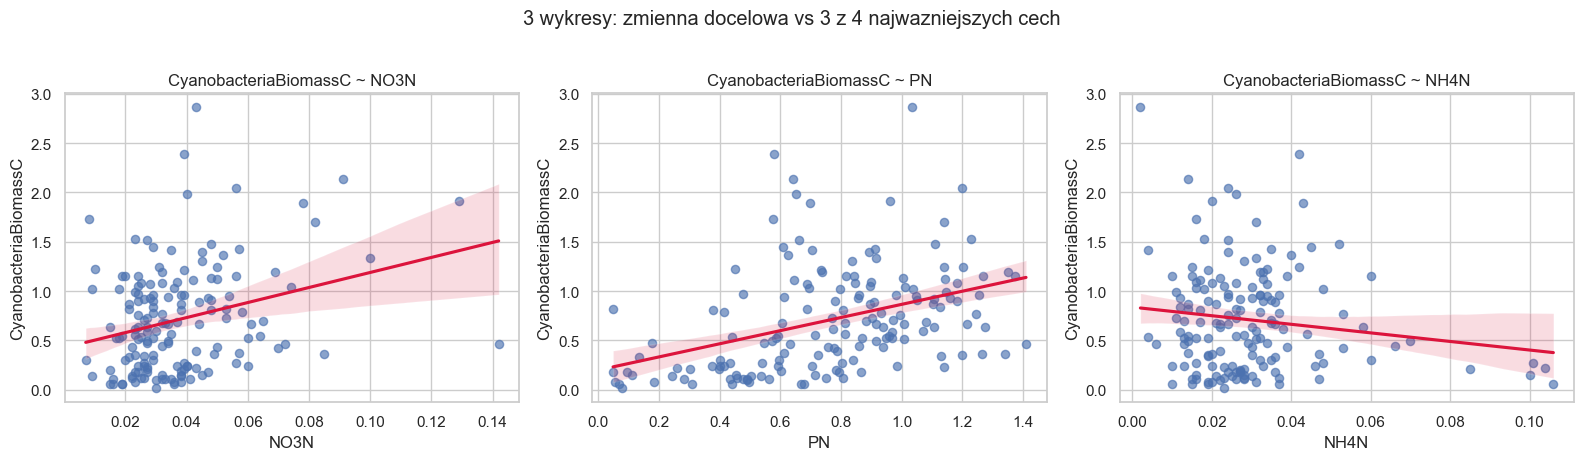

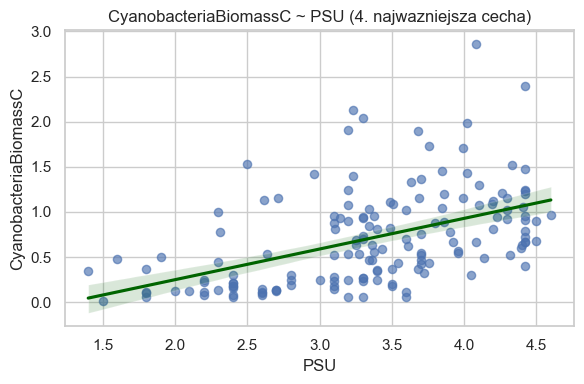

In [16]:
plot_df = df[top4_features + [target_col]].copy()
v1, v2, v3, v4 = top4_features

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_specs = [
    (v1, v2, f'{target_col} vs {v1} (kolor: {v2})'),
    (v3, v4, f'{target_col} vs {v3} (kolor: {v4})'),
    (v1, v3, f'{target_col} vs {v1} (kolor: {v3})'),
]
for ax, (x_name, hue_name, title) in zip(axes, plot_specs):
    sns.scatterplot(
        data=plot_df, x=x_name, y=target_col, hue=hue_name,
        palette='viridis', ax=ax, legend=True,
    )
    ax.set_title(title)

plt.suptitle('3 wykresy: relacje zmiennej docelowej z 4 najwazniejszymi zmiennymi', y=1.03)
plt.tight_layout()
plt.show()

## 8. Eksport HTML

Uruchom w terminalu (z katalogu `RF`):
`jupyter nbconvert --to html task.ipynb`

In [17]:
html_path = base_dir / 'task.html'
graf_path = base_dir / 'graf.html'
tree_svg = ''
if graf_path.exists():
    graf_text = graf_path.read_text(encoding='utf-8', errors='ignore')
    svg_start = graf_text.find('<svg')
    svg_end = graf_text.rfind('</svg>') + len('</svg>')
    if svg_start >= 0 and svg_end > svg_start:
        tree_svg = graf_text[svg_start:svg_end]

summary_html = f"""
<html><head><meta charset='utf-8'><title>RF Cyano – wyniki</title>
<style>body{{font-family:Arial,sans-serif;margin:24px}} table{{border-collapse:collapse}} th,td{{border:1px solid #ccc;padding:6px}}</style>
</head><body>
<h1>Random Forest – biomassa sinic (vlagunr-Cyano.csv)</h1>
<p><b>Problem:</b> hierarchia parametrow srodowiskowych przewidujacych {target_col}</p>
<p><b>Najlepszy wariant (test Accuracy):</b> {best_test['wariant']} = {best_test['Accuracy']:.4f}</p>
<h2>Hierarchia parametrow (model bazowy)</h2>
{hierarchy_df.round(4).to_html(index=False)}
<h2>Oceny – 5 wariantow modelu (train / test)</h2>
{metrics_variants.round(4).to_html(index=False)}
<h2>Porownanie CV: bazowy vs RandomSearchCV vs GridSearchCV</h2>
{metrics_cv.round(4).to_html(index=False)}
<h2>Wybrane zmienne po CV</h2>
<p>RandomSearchCV: {', '.join(random_features)}</p>
<p>GridSearchCV: {', '.join(grid_features)}</p>
<h2>Model drzewa (wizualizacja + oceny)</h2>
<p>Kod: <code>tree_cyano.dot</code> | pelny eksport: <code>graf.html</code> | <a href='http://www.webgraphviz.com/'>WebGraphviz</a></p>
{tree_svg}
<h2>4 najwazniejsze cechy</h2>
<ol>{''.join(f'<li>{f}</li>' for f in top4_features)}</ol>
</body></html>
"""
html_path.write_text(summary_html, encoding='utf-8')
print('Zapisano:', html_path)
if tree_svg:
    print('W task.html osadzono drzewo z graf.html')
else:
    print('Brak SVG w graf.html – wygeneruj drzewo w WebGraphviz i zapisz jako graf.html')

Zapisano: C:\Users\mix13\Documents\GitHub\WBD\PythonProject\RF\task.html
Tabele pomocnicze: metrics_variants.html, metrics_cv.html


In [18]:
display(Markdown(f"""
### Podsumowanie

- **Zmienna docelowa:** `{target_col}`
- **Najwyzsza Accuracy (test):** `{best_test['wariant']}` ({best_test['Accuracy']:.4f})
- **Hierarchia (top 4):** {', '.join(top4_features)}
- **Zmienne po RandomSearchCV:** {', '.join(random_features)}
- **Zmienne po GridSearchCV:** {', '.join(grid_features)}
- Pliki: `task.ipynb`, `task.html`, `tree_cyano.dot`, `graf.html`
"""))


### Podsumowanie

- **Zmienna docelowa:** `CyanobacteriaBiomassC`
- **Najwyzsza Accuracy (test):** `GridSearchCV` (0.3328)
- **Top 4 cechy:** NO3N, PN, NH4N, PSU, PicoplanktonBiomassC, DON, O2, temp., TN/TP, SiO4Si, ChlorophyceaeBiomassC, SS, Fe, Windspeedinsitu, Depth, PP, DOP, DIN to DIP, DiatomsBiomassC, SRP
- Pliki: `task.ipynb`, `task.html`, `tree_cyano.dot`
